In [1]:


from pathlib import Path
import sys
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

print("PHASE 1 — INPUT & MRI VALIDATION")

print("\nPython version:")
print(sys.version)


PHASE 1 — INPUT & MRI VALIDATION

Python version:
3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [15]:
DATASET_ROOT = Path(
    r"C:\3D_DATASET\ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"
)


nested_dataset = (
    DATASET_ROOT /
    "ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"
)

if nested_dataset.exists():
    DATASET_PATH = nested_dataset
else:
    DATASET_PATH = DATASET_ROOT




print("\n" + "=" * 70)
print("DATASET VALIDATION")
print("=" * 70)

print("\nDataset path:")
print(DATASET_PATH)

print("\nDataset exists:", DATASET_PATH.exists())
print("Is directory:", DATASET_PATH.is_dir())


if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"\nDataset was not found at:\n{DATASET_PATH}\n\n"
        "Please check the dataset path."
    )


DATASET VALIDATION

Dataset path:
C:\3D_DATASET\ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData\ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData

Dataset exists: True
Is directory: True


In [16]:


cases = sorted(
    [
        p for p in DATASET_PATH.iterdir()
        if p.is_dir()
    ]
)

print("\nNumber of cases:", len(cases))

if len(cases) == 0:
    raise RuntimeError("No case directories were found.")

print("First case:", cases[0].name)



case_dir = cases[0]

print("\n" + "=" * 70)
print("FIRST CASE")
print("=" * 70)

print("\nCase ID:")
print(case_dir.name)

print("\nCase path:")
print(case_dir)



Number of cases: 1251
First case: BraTS-GLI-00000-000

FIRST CASE

Case ID:
BraTS-GLI-00000-000

Case path:
C:\3D_DATASET\ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData\ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData\BraTS-GLI-00000-000


In [17]:


modalities = {
    "T1": case_dir / f"{case_dir.name}-t1n.nii.gz",
    "T1c": case_dir / f"{case_dir.name}-t1c.nii.gz",
    "T2": case_dir / f"{case_dir.name}-t2w.nii.gz",
    "FLAIR": case_dir / f"{case_dir.name}-t2f.nii.gz",
    "SEG": case_dir / f"{case_dir.name}-seg.nii.gz",
}



print("\n" + "=" * 70)
print("FILE VALIDATION")
print("=" * 70)

all_files_exist = True

for name, path in modalities.items():

    exists = path.exists()

    print(f"\n{name:6} : {'FOUND' if exists else 'MISSING'}")
    print("File   :", path.name)

    if not exists:
        all_files_exist = False


if not all_files_exist:
    raise FileNotFoundError(
        "\nOne or more required MRI files are missing."
    )

print("\n✓ All five required volumes were found.")



FILE VALIDATION

T1     : FOUND
File   : BraTS-GLI-00000-000-t1n.nii.gz

T1c    : FOUND
File   : BraTS-GLI-00000-000-t1c.nii.gz

T2     : FOUND
File   : BraTS-GLI-00000-000-t2w.nii.gz

FLAIR  : FOUND
File   : BraTS-GLI-00000-000-t2f.nii.gz

SEG    : FOUND
File   : BraTS-GLI-00000-000-seg.nii.gz

✓ All five required volumes were found.


In [18]:
# ================================================================
# 9. LOAD ALL FIVE NIFTI VOLUMES
# ================================================================

print("\n" + "=" * 70)
print("LOADING NIFTI VOLUMES")
print("=" * 70)

images = {}
nifti_objects = {}

for name, path in modalities.items():

    try:

        img = nib.load(str(path))

        # get_fdata() gives floating-point data
        data = img.get_fdata()

        nifti_objects[name] = img
        images[name] = data

        print(f"\n✓ {name} loaded successfully")
        print("  Shape :", data.shape)

    except Exception as e:

        print(f"\n✗ Failed to load {name}")
        print("  Error:", e)

        raise


print("\n✓ All five volumes loaded successfully.")



LOADING NIFTI VOLUMES

✓ T1 loaded successfully
  Shape : (240, 240, 155)

✓ T1c loaded successfully
  Shape : (240, 240, 155)

✓ T2 loaded successfully
  Shape : (240, 240, 155)

✓ FLAIR loaded successfully
  Shape : (240, 240, 155)

✓ SEG loaded successfully
  Shape : (240, 240, 155)

✓ All five volumes loaded successfully.


In [19]:



for name, img in nifti_objects.items():

    data = images[name]

    spacing = img.header.get_zooms()[:3]

    print("\n" + "-" * 70)
    print(name)
    print("-" * 70)

    print("File:")
    print(" ", modalities[name].name)

    print("Shape:")
    print(" ", data.shape)

    print("Voxel spacing:")
    print(" ", tuple(float(x) for x in spacing))

    print("Data type:")
    print(" ", data.dtype)

    print("Minimum:")
    print(" ", float(np.min(data)))

    print("Maximum:")
    print(" ", float(np.max(data)))

    print("Mean:")
    print(" ", float(np.mean(data)))

    print("Standard deviation:")
    print(" ", float(np.std(data)))

    non_zero = np.count_nonzero(data)

    print("Non-zero voxels:")
    print(" ", int(non_zero))

    print("Total voxels:")
    print(" ", int(data.size))

    print("Non-zero percentage:")
    print(" ", round((non_zero / data.size) * 100, 4), "%")


----------------------------------------------------------------------
T1
----------------------------------------------------------------------
File:
  BraTS-GLI-00000-000-t1n.nii.gz
Shape:
  (240, 240, 155)
Voxel spacing:
  (1.0, 1.0, 1.0)
Data type:
  float64
Minimum:
  0.0
Maximum:
  2023.0
Mean:
  132.99798633512546
Standard deviation:
  306.4174998580979
Non-zero voxels:
  1480170
Total voxels:
  8928000
Non-zero percentage:
  16.579 %

----------------------------------------------------------------------
T1c
----------------------------------------------------------------------
File:
  BraTS-GLI-00000-000-t1c.nii.gz
Shape:
  (240, 240, 155)
Voxel spacing:
  (1.0, 1.0, 1.0)
Data type:
  float64
Minimum:
  0.0
Maximum:
  12343.0
Mean:
  345.5059033378136
Standard deviation:
  846.7899620988591
Non-zero voxels:
  1480170
Total voxels:
  8928000
Non-zero percentage:
  16.579 %

----------------------------------------------------------------------
T2
------------------------------

In [20]:

# ================================================================
# 11. AFFINE AND ORIENTATION INFORMATION
# ================================================================

print("\n" + "=" * 70)
print("AFFINE & ORIENTATION")
print("=" * 70)

for name, img in nifti_objects.items():

    print("\n" + "-" * 70)
    print(name)
    print("-" * 70)

    print("Affine matrix:")
    print(img.affine)

    orientation = nib.aff2axcodes(img.affine)

    print("\nOrientation:")
    print(" ", orientation)


# ================================================================
# 12. CHECK IMAGE SPACING CONSISTENCY
# ================================================================

print("\n" + "=" * 70)
print("SPACING CONSISTENCY CHECK")
print("=" * 70)

reference_spacing = (
    nifti_objects["T1"]
    .header
    .get_zooms()[:3]
)

print("\nReference spacing (T1):")
print(tuple(float(x) for x in reference_spacing))

spacing_consistent = True

for name, img in nifti_objects.items():

    spacing = img.header.get_zooms()[:3]

    same = np.allclose(
        spacing,
        reference_spacing
    )

    print(
        f"{name:6}: "
        f"{'MATCH' if same else 'DIFFERENT'} "
        f"{tuple(float(x) for x in spacing)}"
    )

    if not same:
        spacing_consistent = False


if spacing_consistent:
    print("\n✓ All five volumes have consistent voxel spacing.")
else:
    print("\n⚠ Some volumes have different voxel spacing.")


AFFINE & ORIENTATION

----------------------------------------------------------------------
T1
----------------------------------------------------------------------
Affine matrix:
[[ -1.  -0.  -0.   0.]
 [ -0.  -1.  -0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]

Orientation:
  ('L', 'P', 'S')

----------------------------------------------------------------------
T1c
----------------------------------------------------------------------
Affine matrix:
[[ -1.  -0.  -0.   0.]
 [ -0.  -1.  -0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]

Orientation:
  ('L', 'P', 'S')

----------------------------------------------------------------------
T2
----------------------------------------------------------------------
Affine matrix:
[[ -1.  -0.  -0.   0.]
 [ -0.  -1.  -0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]

Orientation:
  ('L', 'P', 'S')

----------------------------------------------------------------------
FLAIR
-----------------------------------------

In [21]:
# ================================================================
# 13. CHECK SHAPE CONSISTENCY
# ================================================================

print("\n" + "=" * 70)
print("SHAPE CONSISTENCY CHECK")
print("=" * 70)

reference_shape = images["T1"].shape

print("\nReference shape (T1):")
print(reference_shape)

shape_consistent = True

for name, data in images.items():

    same = data.shape == reference_shape

    print(
        f"{name:6}: "
        f"{'MATCH' if same else 'DIFFERENT'} "
        f"{data.shape}"
    )

    if not same:
        shape_consistent = False


if shape_consistent:
    print("\n✓ All five volumes have identical dimensions.")
else:
    print("\n⚠ Some volumes have different dimensions.")


SHAPE CONSISTENCY CHECK

Reference shape (T1):
(240, 240, 155)
T1    : MATCH (240, 240, 155)
T1c   : MATCH (240, 240, 155)
T2    : MATCH (240, 240, 155)
FLAIR : MATCH (240, 240, 155)
SEG   : MATCH (240, 240, 155)

✓ All five volumes have identical dimensions.


In [22]:
# ================================================================
# 14. CHECK IMAGE / SEGMENTATION COMPATIBILITY
# ================================================================

print("\n" + "=" * 70)
print("IMAGE / SEGMENTATION COMPATIBILITY")
print("=" * 70)

seg_img = nifti_objects["SEG"]
seg_data = images["SEG"]

print("\nImage shape:")
print(images["T1"].shape)

print("Segmentation shape:")
print(seg_data.shape)

if images["T1"].shape == seg_data.shape:
    print("\n✓ T1 and segmentation dimensions match.")
else:
    print("\n✗ T1 and segmentation dimensions DO NOT match.")


print("\nT1 orientation:")
print(nib.aff2axcodes(nifti_objects["T1"].affine))

print("SEG orientation:")
print(nib.aff2axcodes(seg_img.affine))

if (
    nib.aff2axcodes(nifti_objects["T1"].affine)
    ==
    nib.aff2axcodes(seg_img.affine)
):
    print("\n✓ T1 and segmentation orientations match.")
else:
    print("\n⚠ T1 and segmentation orientations differ.")



IMAGE / SEGMENTATION COMPATIBILITY

Image shape:
(240, 240, 155)
Segmentation shape:
(240, 240, 155)

✓ T1 and segmentation dimensions match.

T1 orientation:
('L', 'P', 'S')
SEG orientation:
('L', 'P', 'S')

✓ T1 and segmentation orientations match.


In [23]:


print("SEGMENTATION LABEL ANALYSIS")


# Segmentation masks should contain discrete labels
seg_unique, seg_counts = np.unique(
    seg_data,
    return_counts=True
)

print("\nUnique segmentation values:")

for value, count in zip(seg_unique, seg_counts):

    percentage = (
        count / seg_data.size
    ) * 100

    print(
        f"Label {value:g} : "
        f"{int(count):,} voxels "
        f"({percentage:.4f}%)"
    )
    

SEGMENTATION LABEL ANALYSIS

Unique segmentation values:
Label 0 : 8,870,695 voxels (99.3581%)
Label 1 : 11,738 voxels (0.1315%)
Label 2 : 12,836 voxels (0.1438%)
Label 3 : 32,731 voxels (0.3666%)


In [24]:
# ================================================================
# 16. TUMOR VOXEL CHECK
# ================================================================

tumor_mask = seg_data > 0

tumor_voxels = int(np.count_nonzero(tumor_mask))
total_voxels = int(seg_data.size)

print("\nTumor voxels:")
print(tumor_voxels)

print("\nTumor voxel percentage:")
print(
    round(
        (tumor_voxels / total_voxels) * 100,
        4
    ),
    "%"
)

if tumor_voxels > 0:
    print("\n✓ Tumor is present in the segmentation mask.")
else:
    print("\n⚠ No tumor voxels found in this case.")


# ================================================================
# 17. TUMOR BOUNDING BOX
# ================================================================
#
# This is ONLY inspection.
# No cropping is performed yet.
#
# ================================================================

print("\n" + "=" * 70)
print("TUMOR BOUNDING BOX")
print("=" * 70)

if tumor_voxels > 0:

    tumor_indices = np.argwhere(tumor_mask)

    min_coords = tumor_indices.min(axis=0)
    max_coords = tumor_indices.max(axis=0)

    print("\nMinimum voxel coordinates:")
    print(tuple(int(x) for x in min_coords))

    print("\nMaximum voxel coordinates:")
    print(tuple(int(x) for x in max_coords))

    tumor_size = max_coords - min_coords + 1

    print("\nTumor bounding-box size:")
    print(tuple(int(x) for x in tumor_size))

else:

    print("\nNo tumor bounding box available.")




Tumor voxels:
57305

Tumor voxel percentage:
0.6419 %

✓ Tumor is present in the segmentation mask.

TUMOR BOUNDING BOX

Minimum voxel coordinates:
(118, 45, 49)

Maximum voxel coordinates:
(163, 120, 95)

Tumor bounding-box size:
(46, 76, 47)



VISUALIZATION SLICE

Selected axial slice:
74

Creating MRI visualization...


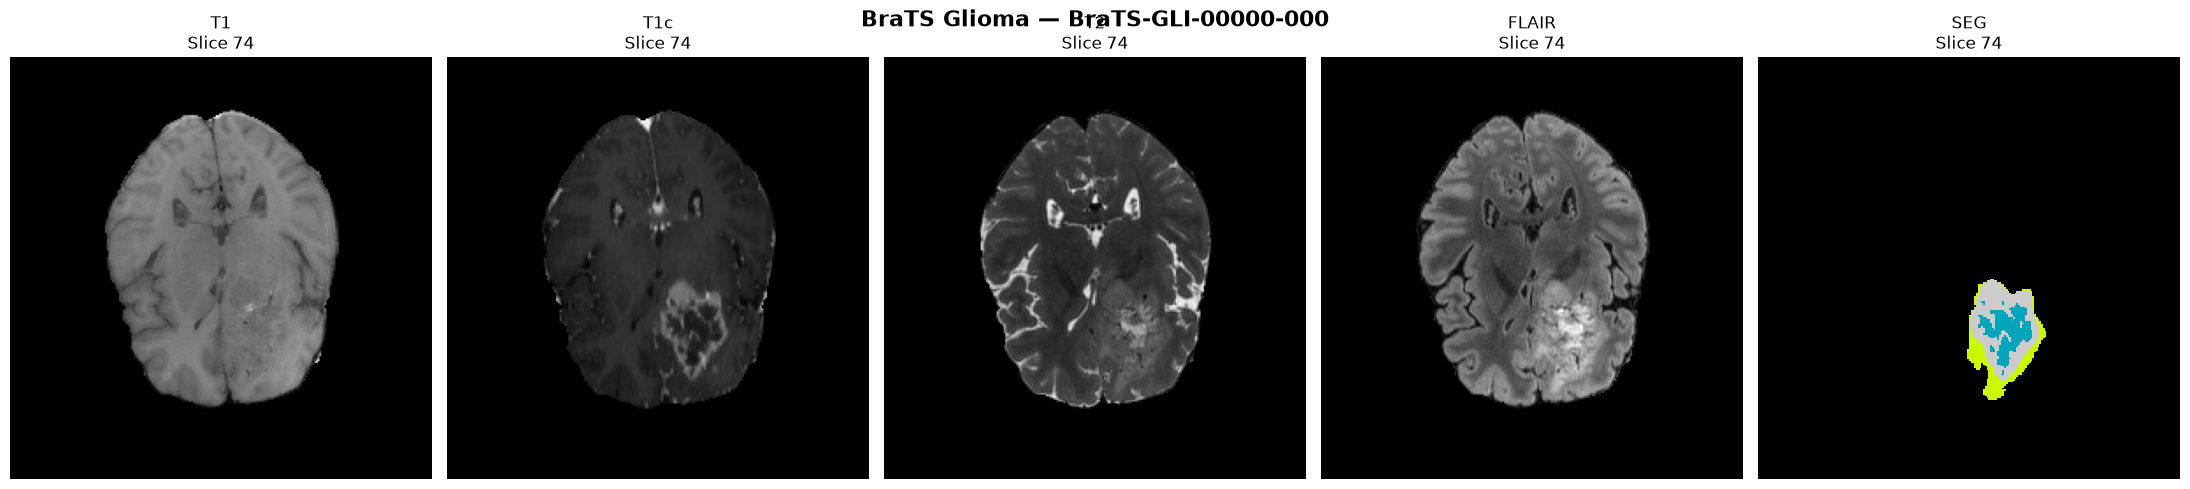

In [25]:


if tumor_voxels > 0:

    tumor_per_slice = tumor_mask.sum(
        axis=(0, 1)
    )

    best_slice = int(
        np.argmax(tumor_per_slice)
    )

else:

    best_slice = images["T1"].shape[2] // 2


print("\n" + "=" * 70)
print("VISUALIZATION SLICE")
print("=" * 70)

print("\nSelected axial slice:")
print(best_slice)


# 19. VISUALIZE ALL FOUR MRI MODALITIES

print("\nCreating MRI visualization...")

fig, axes = plt.subplots(
    1,
    5,
    figsize=(22, 5)
)

display_modalities = [
    "T1",
    "T1c",
    "T2",
    "FLAIR",
    "SEG"
]

for ax, name in zip(axes, display_modalities):

    data = images[name]

    if name == "SEG":

        ax.imshow(
            np.rot90(data[:, :, best_slice]),
            cmap="nipy_spectral",
            interpolation="nearest"
        )

        ax.set_title(
            f"{name}\nSlice {best_slice}"
        )

    else:

        ax.imshow(
            np.rot90(data[:, :, best_slice]),
            cmap="gray"
        )

        ax.set_title(
            f"{name}\nSlice {best_slice}"
        )

    ax.axis("off")


plt.suptitle(
    f"BraTS Glioma — {case_dir.name}",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Creating tumor overlay...


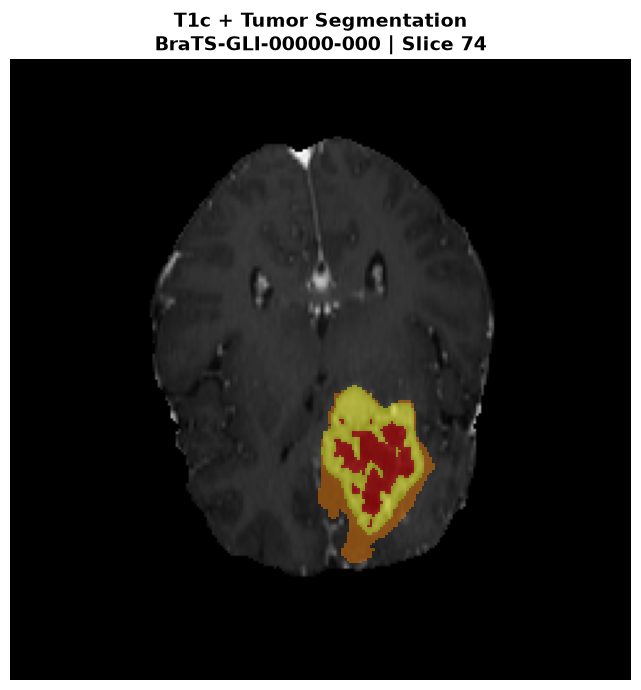


FINAL VALIDATION SUMMARY

Dataset:
  C:\3D_DATASET\ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData\ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData

Number of cases:
  1251

Case inspected:
  BraTS-GLI-00000-000

Required modalities:
  ['T1', 'T1c', 'T2', 'FLAIR', 'SEG']

All files found:
  YES

All volumes loaded:
  YES

Shape consistent:
  YES

Spacing consistent:
  YES

Image/SEG shape compatible:
  YES

Tumor present:
  YES

Selected visualization slice:
  74

PHASE 1 MRI VALIDATION COMPLETE FOR THIS CASE

Next stage:
  Orientation verification
  → Resampling
  → Intensity normalization
  → Cropping
  → Patch extraction


In [26]:
# ================================================================
# 20. MRI + SEGMENTATION OVERLAY
# ================================================================

print("Creating tumor overlay...")

fig, ax = plt.subplots(
    figsize=(7, 7)
)

# MRI background
ax.imshow(
    np.rot90(images["T1c"][:, :, best_slice]),
    cmap="gray"
)

# Segmentation overlay
seg_slice = np.rot90(
    seg_data[:, :, best_slice]
)

masked_seg = np.ma.masked_where(
    seg_slice == 0,
    seg_slice
)

ax.imshow(
    masked_seg,
    cmap="autumn",
    alpha=0.45,
    interpolation="nearest"
)

ax.set_title(
    f"T1c + Tumor Segmentation\n"
    f"{case_dir.name} | Slice {best_slice}",
    fontsize=14,
    fontweight="bold"
)

ax.axis("off")

plt.tight_layout()
plt.show()


# ================================================================
# 21. FINAL VALIDATION SUMMARY
# ================================================================

print("\n" + "=" * 70)
print("FINAL VALIDATION SUMMARY")
print("=" * 70)

print("\nDataset:")
print(" ", DATASET_PATH)

print("\nNumber of cases:")
print(" ", len(cases))

print("\nCase inspected:")
print(" ", case_dir.name)

print("\nRequired modalities:")
print(" ", list(modalities.keys()))

print("\nAll files found:")
print(" ", "YES" if all_files_exist else "NO")

print("\nAll volumes loaded:")
print(" ", "YES")

print("\nShape consistent:")
print(" ", "YES" if shape_consistent else "NO")

print("\nSpacing consistent:")
print(" ", "YES" if spacing_consistent else "NO")

print("\nImage/SEG shape compatible:")
print(
    " ",
    "YES"
    if images["T1"].shape == seg_data.shape
    else "NO"
)

print("\nTumor present:")
print(
    " ",
    "YES"
    if tumor_voxels > 0
    else "NO"
)

print("\nSelected visualization slice:")
print(" ", best_slice)

print("\n" + "=" * 70)
print("PHASE 1 MRI VALIDATION COMPLETE FOR THIS CASE")
print("=" * 70)

print(
    "\nNext stage:"
    "\n  Orientation verification"
    "\n  → Resampling"
    "\n  → Intensity normalization"
    "\n  → Cropping"
    "\n  → Patch extraction"
)

In [27]:
# ============================================================
# MULTI-CASE GLIOMA DATASET INSPECTION
# ============================================================

from pathlib import Path
import nibabel as nib
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# DATASET PATH
# ------------------------------------------------------------

DATASET_ROOT = Path(
    r"C:\3D_DATASET\ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"
) / "ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"

print("Dataset exists:", DATASET_ROOT.exists())
print("Dataset path:", DATASET_ROOT)

# ------------------------------------------------------------
# FIND CASES
# ------------------------------------------------------------

cases = sorted([
    p for p in DATASET_ROOT.iterdir()
    if p.is_dir() and p.name.startswith("BraTS-GLI-")
])

print("Number of cases:", len(cases))

# ------------------------------------------------------------
# SELECT CASES
# ------------------------------------------------------------

# First 10 cases for inspection
selected_cases = cases[:10]

print("\nCases selected:")
for case in selected_cases:
    print(" ", case.name)

# ------------------------------------------------------------
# EXPECTED FILES
# ------------------------------------------------------------

records = []

for case_dir in selected_cases:

    case_name = case_dir.name

    files = {
        "T1": case_dir / f"{case_name}-t1n.nii.gz",
        "T1c": case_dir / f"{case_name}-t1c.nii.gz",
        "T2": case_dir / f"{case_name}-t2w.nii.gz",
        "FLAIR": case_dir / f"{case_name}-t2f.nii.gz",
        "SEG": case_dir / f"{case_name}-seg.nii.gz",
    }

    row = {
        "case": case_name
    }

    # --------------------------------------------------------
    # Check files
    # --------------------------------------------------------

    missing = []

    for modality, path in files.items():

        if not path.exists():
            missing.append(modality)

    row["missing_files"] = ", ".join(missing) if missing else "None"

    # --------------------------------------------------------
    # Load T1
    # --------------------------------------------------------

    try:
        t1_img = nib.load(str(files["T1"]))

        row["shape"] = str(t1_img.shape)
        row["spacing"] = str(
            tuple(round(float(x), 3) for x in t1_img.header.get_zooms()[:3])
        )

        row["orientation"] = str(
            nib.aff2axcodes(t1_img.affine)
        )

        # ----------------------------------------------------
        # Segmentation
        # ----------------------------------------------------

        seg_img = nib.load(str(files["SEG"]))
        seg = seg_img.get_fdata()

        row["seg_shape"] = str(seg.shape)

        row["tumor_voxels"] = int(np.count_nonzero(seg > 0))

        row["tumor_percentage"] = round(
            (np.count_nonzero(seg > 0) / seg.size) * 100,
            4
        )

        # ----------------------------------------------------
        # Alignment
        # ----------------------------------------------------

        row["shape_match"] = (
            t1_img.shape == seg_img.shape
        )

        row["orientation_match"] = (
            nib.aff2axcodes(t1_img.affine)
            == nib.aff2axcodes(seg_img.affine)
        )

        row["spacing_match"] = np.allclose(
            t1_img.header.get_zooms()[:3],
            seg_img.header.get_zooms()[:3]
        )

        row["status"] = "OK"

    except Exception as e:

        row["shape"] = "ERROR"
        row["spacing"] = "ERROR"
        row["orientation"] = "ERROR"
        row["seg_shape"] = "ERROR"
        row["tumor_voxels"] = -1
        row["tumor_percentage"] = -1
        row["shape_match"] = False
        row["orientation_match"] = False
        row["spacing_match"] = False
        row["status"] = f"ERROR: {e}"

    records.append(row)

# ------------------------------------------------------------
# CREATE TABLE
# ------------------------------------------------------------

df = pd.DataFrame(records)

print("\n")
print("=" * 100)
print("MULTI-CASE GLIOMA INSPECTION")
print("=" * 100)

display(df)

# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print("\n")
print("=" * 100)
print("SUMMARY")
print("=" * 100)

print("Cases inspected:", len(df))

print(
    "Cases with missing files:",
    (df["missing_files"] != "None").sum()
)

print(
    "Cases with shape mismatch:",
    (~df["shape_match"]).sum()
)

print(
    "Cases with orientation mismatch:",
    (~df["orientation_match"]).sum()
)

print(
    "Cases with spacing mismatch:",
    (~df["spacing_match"]).sum()
)

print(
    "Cases successfully inspected:",
    (df["status"] == "OK").sum()
)

# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

OUTPUT_DIR = Path("../outputs/dataset_inspection")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

output_file = OUTPUT_DIR / "glioma_multi_case_inspection.csv"

df.to_csv(output_file, index=False)

print("\nSaved:")
print(output_file.resolve())

Dataset exists: True
Dataset path: C:\3D_DATASET\ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData\ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData
Number of cases: 1251

Cases selected:
  BraTS-GLI-00000-000
  BraTS-GLI-00002-000
  BraTS-GLI-00003-000
  BraTS-GLI-00005-000
  BraTS-GLI-00006-000
  BraTS-GLI-00008-000
  BraTS-GLI-00008-001
  BraTS-GLI-00009-000
  BraTS-GLI-00009-001
  BraTS-GLI-00011-000


MULTI-CASE GLIOMA INSPECTION


,case,missing_files,shape,spacing,orientation,seg_shape,tumor_voxels,tumor_percentage,shape_match,orientation_match,spacing_match,status
0,BraTS-GLI-00000-000,None,"(240, 240, 155)","(1.0, 1.0, 1.0)","('L', 'P', 'S')","(240, 240, 155)",57305,0.6419,True,True,True,OK
1,BraTS-GLI-00002-000,None,"(240, 240, 155)","(1.0, 1.0, 1.0)","('L', 'P', 'S')","(240, 240, 155)",190594,2.1348,True,True,True,OK
2,BraTS-GLI-00003-000,None,"(240, 240, 155)","(1.0, 1.0, 1.0)","('L', 'P', 'S')","(240, 240, 155)",99239,1.1115,True,True,True,OK
3,BraTS-GLI-00005-000,None,"(240, 240, 155)","(1.0, 1.0, 1.0)","('L', 'P', 'S')","(240, 240, 155)",124783,1.3977,True,True,True,OK
4,BraTS-GLI-00006-000,None,"(240, 240, 155)","(1.0, 1.0, 1.0)","('L', 'P', 'S')","(240, 240, 155)",137911,1.5447,True,True,True,OK
5,BraTS-GLI-00008-000,None,"(240, 240, 155)","(1.0, 1.0, 1.0)","('L', 'P', 'S')","(240, 240, 155)",18462,0.2068,True,True,True,OK
6,BraTS-GLI-00008-001,None,"(240, 240, 155)","(1.0, 1.0, 1.0)","('L', 'P', 'S')","(240, 240, 155)",15526,0.1739,True,True,True,OK
7,BraTS-GLI-00009-000,None,"(240, 240, 155)","(1.0, 1.0, 1.0)","('L', 'P', 'S')","(240, 240, 155)",27453,0.3075,True,True,True,OK
8,BraTS-GLI-00009-001,None,"(240, 240, 155)","(1.0, 1.0, 1.0)","('L', 'P', 'S')","(240, 240, 155)",27091,0.3034,True,True,True,OK
9,BraTS-GLI-00011-000,None,"(240, 240, 155)","(1.0, 1.0, 1.0)","('L', 'P', 'S')","(240, 240, 155)",70184,0.7861,True,True,True,OK




SUMMARY
Cases inspected: 10
Cases with missing files: 0
Cases with shape mismatch: 0
Cases with orientation mismatch: 0
Cases with spacing mismatch: 0
Cases successfully inspected: 10

Saved:
C:\Users\nchan\Desktop\DL\outputs\dataset_inspection\glioma_multi_case_inspection.csv


Case: BraTS-GLI-00000-000
Selected tumor slice: 74
Tumor voxels on slice: 1978


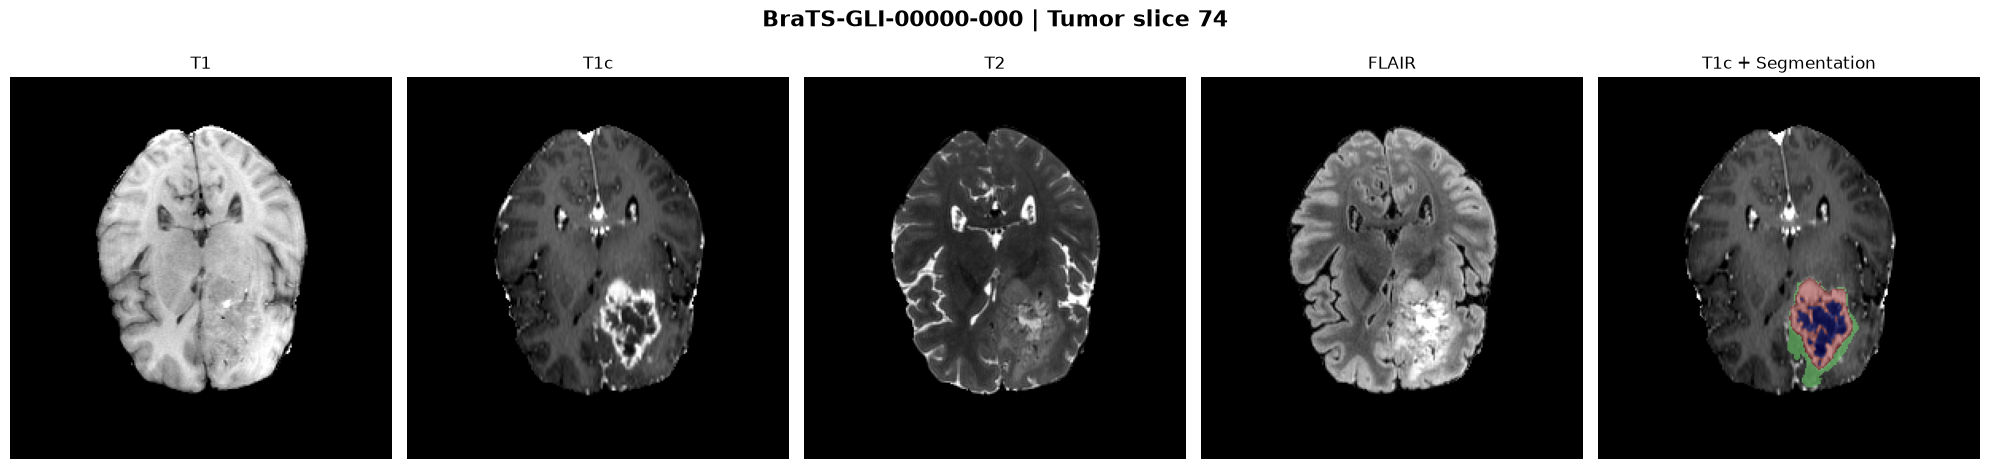


Saved visualization:
C:\Users\nchan\Desktop\DL\outputs\dataset_inspection\BraTS-GLI-00000-000_tumor_visualization.png


In [28]:
# ============================================================
# AUTOMATIC TUMOR SLICE VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np

# ------------------------------------------------------------
# CASE
# ------------------------------------------------------------

case_dir = cases[0]
case_name = case_dir.name

t1_path = case_dir / f"{case_name}-t1n.nii.gz"
t1c_path = case_dir / f"{case_name}-t1c.nii.gz"
t2_path = case_dir / f"{case_name}-t2w.nii.gz"
flair_path = case_dir / f"{case_name}-t2f.nii.gz"
seg_path = case_dir / f"{case_name}-seg.nii.gz"

# ------------------------------------------------------------
# LOAD
# ------------------------------------------------------------

t1 = nib.load(str(t1_path)).get_fdata()
t1c = nib.load(str(t1c_path)).get_fdata()
t2 = nib.load(str(t2_path)).get_fdata()
flair = nib.load(str(flair_path)).get_fdata()
seg = nib.load(str(seg_path)).get_fdata()

# ------------------------------------------------------------
# FIND SLICE WITH MAXIMUM TUMOR
# ------------------------------------------------------------

tumor_counts = np.count_nonzero(seg > 0, axis=(0, 1))

best_slice = int(np.argmax(tumor_counts))

print("Case:", case_name)
print("Selected tumor slice:", best_slice)
print("Tumor voxels on slice:", tumor_counts[best_slice])

# ------------------------------------------------------------
# NORMALIZATION FUNCTION
# ------------------------------------------------------------

def display_normalize(image):

    image = image.astype(np.float32)

    nonzero = image[image > 0]

    if len(nonzero) == 0:
        return image

    p1 = np.percentile(nonzero, 1)
    p99 = np.percentile(nonzero, 99)

    image = np.clip(image, p1, p99)

    image = (image - p1) / (p99 - p1 + 1e-8)

    return image

# ------------------------------------------------------------
# EXTRACT SLICE
# ------------------------------------------------------------

t1_slice = display_normalize(t1[:, :, best_slice])
t1c_slice = display_normalize(t1c[:, :, best_slice])
t2_slice = display_normalize(t2[:, :, best_slice])
flair_slice = display_normalize(flair[:, :, best_slice])

seg_slice = seg[:, :, best_slice]

# ------------------------------------------------------------
# VISUALIZATION
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

images_to_show = [
    (t1_slice, "T1"),
    (t1c_slice, "T1c"),
    (t2_slice, "T2"),
    (flair_slice, "FLAIR"),
]

for ax, (image, title) in zip(axes[:4], images_to_show):

    ax.imshow(
        image.T,
        cmap="gray",
        origin="lower"
    )

    ax.set_title(title)
    ax.axis("off")

# ------------------------------------------------------------
# SEGMENTATION OVERLAY
# ------------------------------------------------------------

axes[4].imshow(
    t1c_slice.T,
    cmap="gray",
    origin="lower"
)

mask = np.ma.masked_where(
    seg_slice.T == 0,
    seg_slice.T
)

axes[4].imshow(
    mask,
    cmap="jet",
    alpha=0.45,
    origin="lower"
)

axes[4].set_title("T1c + Segmentation")
axes[4].axis("off")

plt.suptitle(
    f"{case_name} | Tumor slice {best_slice}",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

# ------------------------------------------------------------
# SAVE FIGURE
# ------------------------------------------------------------

VIS_DIR = Path("../outputs/dataset_inspection")
VIS_DIR.mkdir(parents=True, exist_ok=True)

save_path = VIS_DIR / f"{case_name}_tumor_visualization.png"

plt.savefig(
    save_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nSaved visualization:")
print(save_path.resolve())